<h1 style="color:#56B4E9;">Week 7 — Day 3</h1>

<h2 style="color:#0072B2;">RNNs & LSTMs for Sequential ECG Data</h2>

### ECG Heartbeat Classification

During the previous days, we studied image classification using Convolutional Neural Networks. Images contain spatial relationships, so CNNs examine neighboring pixels and learn visual patterns such as edges, textures, and shapes.

Today, we move to a different type of data: sequential ECG signals.

An ECG heartbeat is not simply a collection of independent numerical values. Each measurement occurs at a specific time, and its meaning depends on the measurements that came before and after it. Changing the order of the readings changes the shape and meaning of the heartbeat.

For this reason, today we will study models designed specifically for sequential data:

- A non-recurrent Dense baseline.
- A Simple Recurrent Neural Network.
- A Long Short-Term Memory network.

The main objective is not only to obtain a classification result, but to understand how memory and temporal order affect the model's ability to recognize heartbeat patterns.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Explain why the order of ECG measurements is important.
- Explain how an RNN processes a sequence one time step at a time.
- Understand how the hidden state carries information through a sequence.
- Explain the vanishing-gradient problem in plain RNNs.
- Explain how LSTM gates help preserve useful information.
- Prepare ECG signals in the three-dimensional format expected by recurrent layers.
- Build a non-recurrent baseline, a Simple RNN, and an LSTM.
- Compare the models using validation performance and medical classification metrics.
- Examine recall for each heartbeat category instead of depending only on accuracy.
- Explain whether recurrent memory provided a practical benefit on this dataset.

<h2 style="color:#0072B2;">Day 3 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>  
A heartbeat is represented by a sequence of measurements collected over time. Treating these measurements as unrelated values may ignore important temporal relationships inside the ECG waveform.

<span style="color:#009E73;"><b>Today's Goal:</b></span>  
Build models that process the heartbeat as an ordered sequence and determine whether recurrent memory improves heartbeat classification.

### Experimental Sequence

1. Download and inspect the ECG Heartbeat Categorization Dataset.
2. Select the MIT-BIH arrhythmia collection.
3. Separate the ECG measurements from the class labels.
4. Examine the class distribution and visualize heartbeat sequences.
5. Create a stratified validation split from the training data.
6. Keep the provided test set untouched.
7. Build a non-recurrent Dense baseline.
8. Build a Simple RNN.
9. Build an LSTM.
10. Compare validation accuracy, balanced accuracy, Macro Recall, Macro F1, and training time.
11. Select the final model using validation results.
12. Evaluate the selected model once on the untouched test set.

<span style="color:#D55E00;"><b>Evaluation Rule:</b></span>  
The test set will not be used to choose the model. It will only be opened after the final model has been selected using validation results.

<h2 style="color:#0072B2;">3.1 Dataset Selection</h2>

The ECG Heartbeat Categorization Dataset contains two processed ECG collections:

1. The MIT-BIH Arrhythmia Dataset.
2. The PTB Diagnostic ECG Database.

For today's experiment, we will use the MIT-BIH collection because it provides a multi-class sequential classification problem with separate training and test files.

The selected files are:

- `mitbih_train.csv`
- `mitbih_test.csv`

Each row represents one segmented heartbeat.

- The first `187` columns contain ordered ECG measurements.
- The final column contains the heartbeat class.
- The signal was sampled at `125 Hz`.
- Each heartbeat belongs to one of five categories.

### Heartbeat Categories

| Label | Symbol | General Meaning |
|---:|:---:|---|
| 0 | N | Normal heartbeat |
| 1 | S | Supraventricular ectopic heartbeat |
| 2 | V | Ventricular ectopic heartbeat |
| 3 | F | Fusion heartbeat |
| 4 | Q | Unknown or unclassified heartbeat |

The dataset has already been segmented, normalized, downsampled, and padded when necessary. Therefore, the purpose of today's preprocessing is to prepare the model input rather than repeat the original signal-processing pipeline.

Dataset source:  
https://www.kaggle.com/datasets/shayanfazeli/heartbeat

In [2]:
from pathlib import Path
import random
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Input,
    Dense,
    Flatten,
    SimpleRNN,
    LSTM
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment prepared successfully.")
print("TensorFlow version:", tf.__version__)

Environment prepared successfully.
TensorFlow version: 2.21.0


<h3 style="color:#009E73;">Environment Preparation</h3>

The required libraries are now available.

The random seed is fixed at `42` to make the data split and model initialization more reproducible.

The experiment will use:

- Pandas and NumPy for data preparation.
- Matplotlib for ECG visualization.
- Scikit-learn for splitting and evaluation.
- TensorFlow and Keras for building the Dense, RNN, and LSTM models.

In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "shayanfazeli/heartbeat"
    )
)

train_file = next(
    dataset_path.rglob("mitbih_train.csv")
)

test_file = next(
    dataset_path.rglob("mitbih_test.csv")
)

print("Dataset path:")
print(dataset_path)

print("\nTraining file:")
print(train_file)

print("\nTest file:")
print(test_file)

100%|██████████| 98.8M/98.8M [00:03<00:00, 26.0MB/s]

Extracting files...


Dataset path:
/home/haitham/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1

Training file:
/home/haitham/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1/mitbih_train.csv

Test file:
/home/haitham/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1/mitbih_test.csv


<h2 style="color:#0072B2;">3.2 Loading the MIT-BIH Data</h2>

The dataset is stored in CSV format without column names.

Each row contains:

$$
187\ \text{ECG measurements} + 1\ \text{class label}
$$

The original training and test files will be loaded separately.

Keeping these files separate is important because the provided test data must not influence model training or model selection.

In [4]:
train_data = pd.read_csv(
    train_file,
    header=None
)

test_data = pd.read_csv(
    test_file,
    header=None
)

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

display(train_data.head())

Training data shape: (87554, 188)
Test data shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<h3 style="color:#009E73;">Initial Dataset Structure</h3>

The table confirms that each row contains one heartbeat.

The first `187` values represent the ECG signal in temporal order, while column `187` contains the class label.

The measurements are already represented using numerical values between approximately `0` and `1`.

The zeros appearing near the end of some rows may represent padding added to make all heartbeat sequences the same length.

These zeros should not be treated as missing values.

In [5]:
X_full_train = train_data.iloc[:, :-1].to_numpy(
    dtype=np.float32
)

y_full_train = train_data.iloc[:, -1].to_numpy(
    dtype=np.int32
)

X_test = test_data.iloc[:, :-1].to_numpy(
    dtype=np.float32
)

y_test = test_data.iloc[:, -1].to_numpy(
    dtype=np.int32
)

print("Training signals:", X_full_train.shape)
print("Training labels:", y_full_train.shape)

print("\nTest signals:", X_test.shape)
print("Test labels:", y_test.shape)

print(
    "\nTraining signal range:",
    X_full_train.min(),
    "to",
    X_full_train.max()
)

print(
    "Missing training values:",
    np.isnan(X_full_train).sum()
)

print(
    "Infinite training values:",
    np.isinf(X_full_train).sum()
)

print(
    "Detected training classes:",
    np.unique(y_full_train)
)

Training signals: (87554, 187)
Training labels: (87554,)

Test signals: (21892, 187)
Test labels: (21892,)

Training signal range: 0.0 to 1.0
Missing training values: 0
Infinite training values: 0
Detected training classes: [0 1 2 3 4]


<h3 style="color:#009E73;">Signal and Label Separation</h3>

The ECG measurements and class labels are now stored separately.

The expected shapes are:

- Training signals: `(87554, 187)`
- Training labels: `(87554,)`
- Test signals: `(21892, 187)`
- Test labels: `(21892,)`

At this stage, each heartbeat is represented as a two-dimensional table:

$$
(\text{samples},\ \text{time steps})
$$

The recurrent models require a third dimension representing the number of features available at every time step:

$$
(\text{samples},\ \text{time steps},\ \text{features})
$$

Because there is one ECG measurement at every time step, the final input shape will be:

$$
(\text{samples},\ 187,\ 1)
$$

In [6]:
class_names = {
    0: "N - Normal",
    1: "S - Supraventricular",
    2: "V - Ventricular",
    3: "F - Fusion",
    4: "Q - Unclassified"
}

class_distribution = (
    pd.Series(y_full_train)
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Class Name"] = (
    class_distribution["Class"]
    .map(class_names)
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / class_distribution["Count"].sum()
    * 100
)

display(class_distribution.round(2))

,Class,Count,Class Name,Percentage
0,0,72471,N - Normal,82.77
1,1,2223,S - Supraventricular,2.54
2,2,5788,V - Ventricular,6.61
3,3,641,F - Fusion,0.73
4,4,6431,Q - Unclassified,7.35


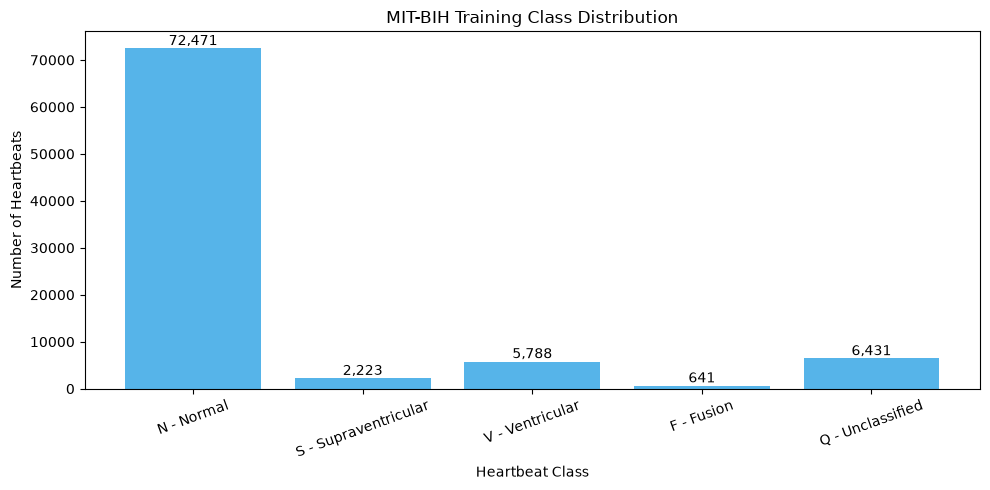

In [7]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    class_distribution["Class Name"],
    class_distribution["Count"],
    color="#56B4E9"
)

plt.title("MIT-BIH Training Class Distribution")
plt.xlabel("Heartbeat Class")
plt.ylabel("Number of Heartbeats")
plt.xticks(rotation=20)

for bar, count in zip(
    bars,
    class_distribution["Count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

<h3 style="color:#D55E00;">Class-Imbalance Problem</h3>

The class-distribution table and chart show that the dataset is highly imbalanced.

The normal class contains substantially more examples than some abnormal heartbeat categories. Therefore, a model could achieve high accuracy by concentrating mainly on the majority class while performing poorly on rare abnormal classes.

For this reason, accuracy alone will not be sufficient.

The comparison will also include:

- Balanced Accuracy.
- Macro Recall.
- Macro F1.
- Recall for every heartbeat class.
- A confusion matrix.

`Macro Recall` calculates recall separately for every class and then gives all classes equal importance, regardless of their sample counts.

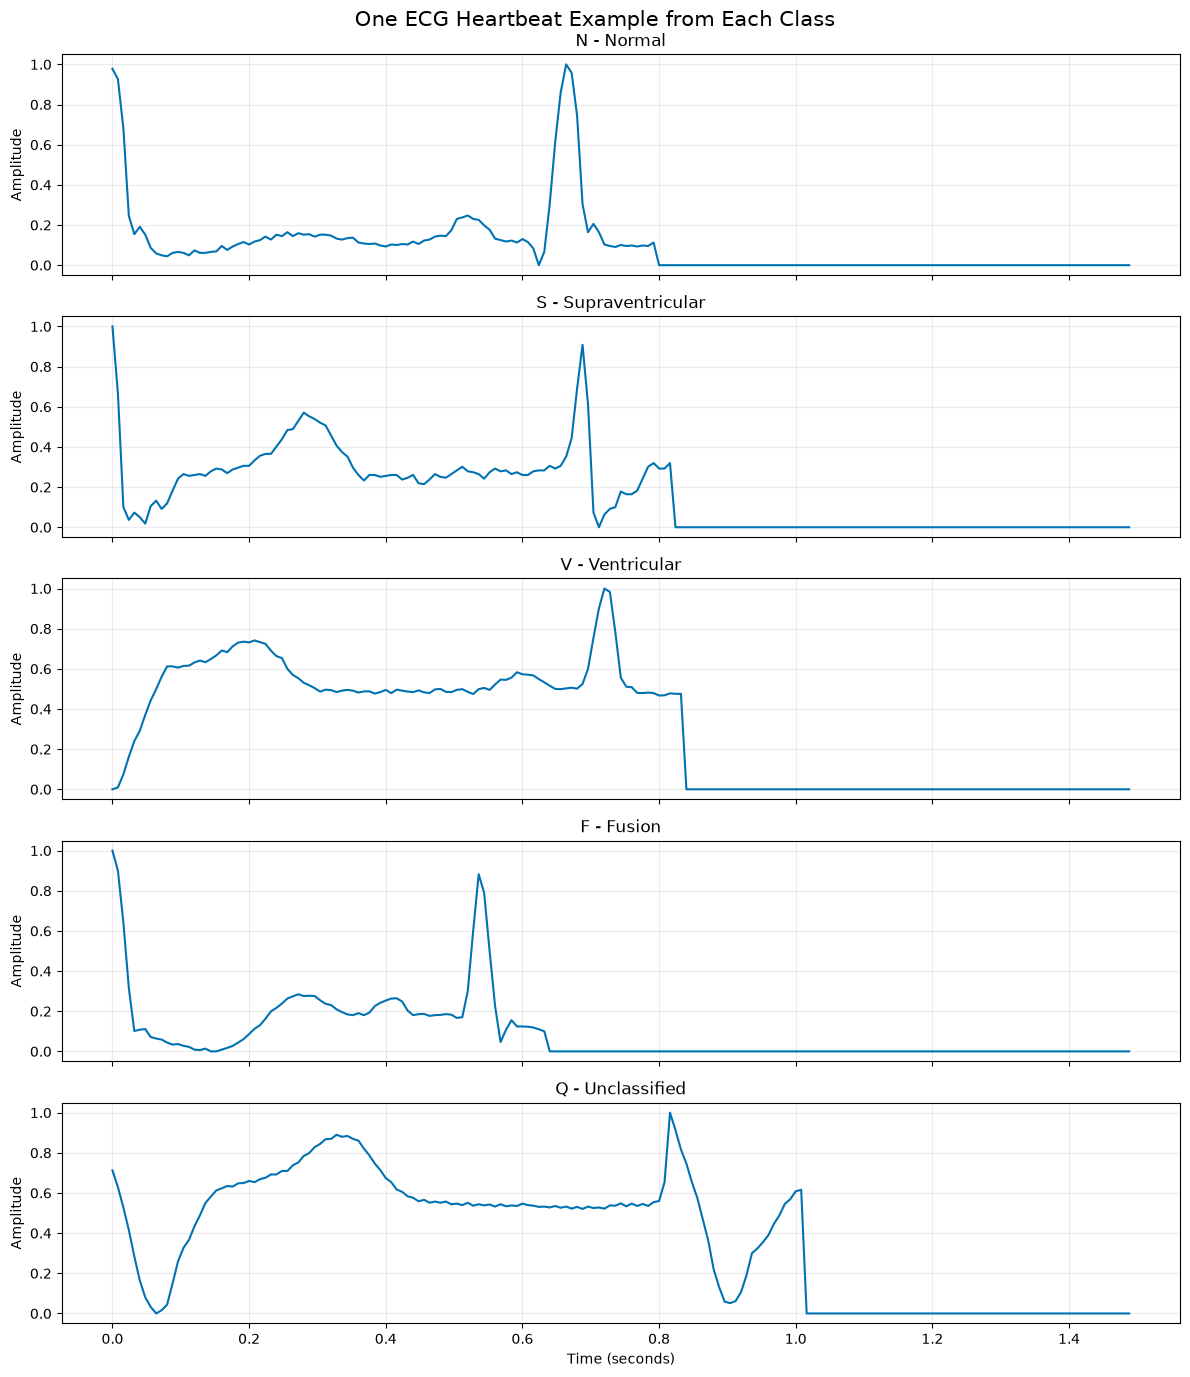

In [8]:
sampling_frequency = 125

time_axis = (
    np.arange(X_full_train.shape[1])
    / sampling_frequency
)

fig, axes = plt.subplots(
    5,
    1,
    figsize=(12, 14),
    sharex=True
)

for class_id, axis in enumerate(axes):
    sample_index = np.where(
        y_full_train == class_id
    )[0][0]

    axis.plot(
        time_axis,
        X_full_train[sample_index],
        color="#0072B2",
        linewidth=1.5
    )

    axis.set_title(
        class_names[class_id]
    )

    axis.set_ylabel(
        "Amplitude"
    )

    axis.grid(
        alpha=0.25
    )

axes[-1].set_xlabel(
    "Time (seconds)"
)

plt.suptitle(
    "One ECG Heartbeat Example from Each Class",
    fontsize=15
)

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.3 Why Order Matters in ECG Data</h2>

The previous plots show that heartbeat categories are represented by different waveform patterns.

A heartbeat is not defined only by the numerical values it contains. It is also defined by:

- When a rise occurs.
- When a peak appears.
- How quickly the signal falls.
- What pattern follows the peak.
- How earlier and later measurements relate to each other.

The ECG measurements form an ordered sequence:

$$
x_1 \rightarrow x_2 \rightarrow x_3
\rightarrow \cdots \rightarrow x_{187}
$$

If these values are randomly shuffled, the sequence still contains the same numerical values, but the ECG waveform and its temporal meaning are destroyed.

This is why an order-aware architecture is appropriate.

A recurrent model processes one measurement at a time and carries information from previous measurements through a hidden state.

For a Simple RNN, the hidden state is updated using:

$$
h_t =
\tanh
\left(
W_xx_t + W_hh_{t-1} + b
\right)
$$

Where:

- $x_t$ is the ECG measurement at the current time step.
- $h_{t-1}$ is the hidden state from the previous time step.
- $h_t$ is the updated hidden state.
- $W_x$ contains the weights applied to the current input.
- $W_h$ contains the recurrent weights applied to the previous hidden state.
- $b$ is the bias.
- $\tanh$ limits the hidden-state values to the range `[-1, 1]`.

The final hidden representation summarizes information collected while the model moves through the heartbeat sequence and can then be used for classification.

<h2 style="color:#0072B2;">3.4 Training, Validation, and Test Separation</h2>

The provided MIT-BIH test set will remain untouched.

A validation subset will be created from the original training file using stratified splitting.

Stratification preserves approximately the same class proportions in the training and validation sets.

The split will therefore be:

- `80%` of the original training file for model training.
- `20%` of the original training file for validation.
- The complete provided test file for final evaluation only.

In [9]:
X_train, X_validation, y_train, y_validation = (
    train_test_split(
        X_full_train,
        y_full_train,
        test_size=0.20,
        random_state=SEED,
        stratify=y_full_train
    )
)

split_summary = pd.DataFrame([
    {
        "Split": "Training",
        "Samples": len(X_train)
    },
    {
        "Split": "Validation",
        "Samples": len(X_validation)
    },
    {
        "Split": "Test",
        "Samples": len(X_test)
    }
])

display(split_summary)

print(
    "Training classes:",
    np.bincount(y_train)
)

print(
    "Validation classes:",
    np.bincount(y_validation)
)

print(
    "Test classes:",
    np.bincount(y_test)
)

,Split,Samples
0,Training,70043
1,Validation,17511
2,Test,21892


Training classes: [57977  1778  4630   513  5145]
Validation classes: [14494   445  1158   128  1286]
Test classes: [18118   556  1448   162  1608]


<h3 style="color:#009E73;">Stratified Split Result</h3>

The training, validation, and test sets are now separated.

The validation data will be used to:

- Monitor model performance after each epoch.
- Detect overfitting.
- Compare the Dense, Simple RNN, and LSTM models.
- Select the final model.

The test data will not participate in any of these decisions.

In [10]:
X_train_sequence = X_train[..., np.newaxis]
X_validation_sequence = X_validation[..., np.newaxis]
X_test_sequence = X_test[..., np.newaxis]

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Sequential training shape:",
    X_train_sequence.shape
)

print(
    "Sequential validation shape:",
    X_validation_sequence.shape
)

print(
    "Sequential test shape:",
    X_test_sequence.shape
)

Original training shape: (70043, 187)
Sequential training shape: (70043, 187, 1)
Sequential validation shape: (17511, 187, 1)
Sequential test shape: (21892, 187, 1)


<h3 style="color:#009E73;">Sequential Input Preparation</h3>

The recurrent-model input is now three-dimensional:

$$
(\text{samples},\ \text{time steps},\ \text{features})
$$

For this experiment:

- `samples` represents the number of heartbeats.
- `time steps = 187`.
- `features = 1`, because every time step contains one ECG amplitude value.

Therefore, one heartbeat enters the recurrent model with the following shape:

$$
(187,\ 1)
$$

The first number represents the number of ordered time steps, while the second represents the number of features available at each time step.

No `Embedding` layer is required.

Embedding layers are commonly used to convert discrete word indices into learned numerical vectors. Our ECG inputs are already continuous numerical measurements, so they can enter the recurrent layers directly.

<h2 style="color:#0072B2;">3.5 The Vanishing-Gradient Problem</h2>

A Simple RNN passes its hidden state from one time step to the next.

During forward propagation, this allows information from earlier ECG measurements to influence later calculations.

During training, however, the error gradient must travel backward through all previous time steps.

The gradient reaching an earlier hidden state can be represented conceptually as:

$$
\frac{\partial L}{\partial h_{t-k}}
=
\frac{\partial L}{\partial h_t}
\prod_{j=t-k+1}^{t}
\frac{\partial h_j}{\partial h_{j-1}}
$$

Where:

- $L$ is the model loss.
- $h_t$ is a later hidden state.
- $h_{t-k}$ is an earlier hidden state.
- The product represents repeated gradient propagation through time.

If most values inside the product are smaller than `1`, repeatedly multiplying them causes the gradient to become extremely small:

$$
0.5^{10} \approx 0.00098
$$

This is called the **vanishing-gradient problem**.

When the gradient becomes very small, early time steps receive almost no useful parameter updates. The RNN may therefore struggle to learn relationships between distant parts of the ECG sequence.

The opposite situation can also occur. If the repeated values are larger than `1`, the gradient may grow rapidly, producing an **exploding gradient**.

Plain RNNs can model short sequential relationships, but they often struggle to preserve useful information across longer sequences.

<h2 style="color:#0072B2;">3.6 How LSTM Memory Works</h2>

An LSTM is a recurrent architecture designed to preserve useful information over longer sequences.

In addition to the hidden state $h_t$, the LSTM maintains a cell state $c_t$, which acts as a longer-term memory path.

The LSTM controls this memory using gates.

### Forget Gate

The forget gate decides how much of the previous memory should remain:

$$
f_t =
\sigma
\left(
W_f[h_{t-1},x_t] + b_f
\right)
$$

A value close to `0` means forget the information, while a value close to `1` means preserve it.

### Input Gate

The input gate decides how much new information should enter the memory:

$$
i_t =
\sigma
\left(
W_i[h_{t-1},x_t] + b_i
\right)
$$

The model also creates a candidate memory:

$$
\tilde{c}_t =
\tanh
\left(
W_c[h_{t-1},x_t] + b_c
\right)
$$

### Cell-State Update

The new cell state combines preserved old information with selected new information:

$$
c_t =
f_t \odot c_{t-1}
+
i_t \odot \tilde{c}_t
$$

### Output Gate

The output gate determines which part of the cell state becomes the current hidden state:

$$
o_t =
\sigma
\left(
W_o[h_{t-1},x_t] + b_o
\right)
$$

$$
h_t =
o_t \odot \tanh(c_t)
$$

Because the LSTM can learn what to retain, update, and forget, it can preserve relevant temporal information more effectively than a plain RNN.

A GRU follows a similar idea but combines some of these operations into fewer gates. It is usually simpler and faster, while the LSTM provides a separate cell state and more explicit memory control.

The practical experiment will focus on LSTM because it directly demonstrates the gated-memory concept required in today's lesson.

<h2 style="color:#0072B2;">3.7 Experimental Model Design</h2>

Three models will be trained under similar conditions.

### Model 1: Dense Baseline

The Dense model receives the `187` measurements together as a fixed vector.

It does not carry a hidden state from one time step to another. It therefore provides a non-recurrent baseline.

### Model 2: Simple RNN

The Simple RNN reads the ECG measurements sequentially and updates a hidden state at every time step.

It can use temporal context but may suffer from vanishing gradients.

### Model 3: LSTM

The LSTM also processes the ECG sequentially, but its gates control what information should be remembered or forgotten.

### Output Layer

All models use five output neurons with a Softmax activation.

For class $c$, Softmax calculates:

$$
P(y=c \mid x)
=
\frac{e^{z_c}}
{\sum_{j=1}^{5}e^{z_j}}
$$

The five probabilities sum to `1`.

The predicted class is the class with the highest probability:

$$
\hat{y}
=
\operatorname*{arg\,max}_{c}
P(y=c \mid x)
$$

Because the correct label is represented as an integer from `0` to `4`, the models will use `sparse_categorical_crossentropy`.

In [11]:
from sklearn.metrics import fbeta_score
from sklearn.utils.class_weight import compute_class_weight


detected_classes = np.unique(y_train)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=detected_classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        detected_classes,
        balanced_weights
    )
}

class_weight_table = pd.DataFrame({
    "Class": detected_classes,
    "Class Name": [
        class_names[class_id]
        for class_id in detected_classes
    ],
    "Weight": balanced_weights
})

display(class_weight_table.round(4))

,Class,Class Name,Weight
0,0,N - Normal,0.2416
1,1,S - Supraventricular,7.8789
2,2,V - Ventricular,3.0256
3,3,F - Fusion,27.3072
4,4,Q - Unclassified,2.7228


<h3 style="color:#009E73;">Class Weights</h3>

Class weights reduce the effect of the large class imbalance.

The balanced weight for class $c$ is calculated using:

$$
w_c =
\frac{N}
{K \times n_c}
$$

Where:

- $N$ is the total number of training samples.
- $K$ is the number of classes.
- $n_c$ is the number of training samples belonging to class $c$.
- $w_c$ is the weight assigned to errors from class $c$.

Large classes receive smaller weights, while rare classes receive larger weights.

This does not create new samples. It changes the importance of each training error so that the model cannot obtain a low loss simply by concentrating on the normal class.

In [12]:
EPOCHS = 12
BATCH_SIZE = 256


def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=3,
            restore_best_weights=True
        )
    ]


def plot_training_history(history, model_name):
    epochs_range = range(
        1,
        len(history.history["loss"]) + 1
    )

    plt.figure(figsize=(13, 4))

    plt.subplot(1, 2, 1)
    plt.plot(
        epochs_range,
        history.history["accuracy"],
        marker="o",
        label="Training Accuracy"
    )
    plt.plot(
        epochs_range,
        history.history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)

    plt.subplot(1, 2, 2)
    plt.plot(
        epochs_range,
        history.history["loss"],
        marker="o",
        label="Training Loss"
    )
    plt.plot(
        epochs_range,
        history.history["val_loss"],
        marker="o",
        label="Validation Loss"
    )
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


print("Maximum epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Early stopping patience: 3")

Maximum epochs: 12
Batch size: 256
Early stopping patience: 3


<h2 style="color:#0072B2;">3.8 Model 1 — Dense Baseline</h2>

The first model provides a non-recurrent baseline.

It receives the heartbeat as a flat vector containing `187` values.

Unlike the RNN and LSTM, it does not:

- Read the sequence one step at a time.
- Maintain a hidden state.
- Reuse the same recurrent transformation across time.
- Explicitly carry information between time steps.

However, the Dense model can still learn patterns associated with fixed input positions. It is therefore a useful baseline for determining whether recurrent processing provides an additional practical benefit.

The final layer contains five Softmax neurons, one for each heartbeat category.

In [13]:
dense_model = Sequential([
    Input(shape=(187,)),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        5,
        activation="softmax"
    )
])

dense_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

E0000 00:00:1788283479.927019    4298 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,277 (55.77 KB)

 Trainable params: 14,277 (55.77 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
start_time = time.time()

dense_history = dense_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks(),
    verbose=1
)

dense_training_time = (
    time.time() - start_time
)

print(
    "\nDense training time:",
    f"{dense_training_time / 60:.2f} minutes"
)

Epoch 1/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5239 - loss: 0.9619 - val_accuracy: 0.7021 - val_loss: 0.8361
Epoch 2/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7170 - loss: 0.6091 - val_accuracy: 0.7659 - val_loss: 0.6768
Epoch 3/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7624 - loss: 0.5073 - val_accuracy: 0.7366 - val_loss: 0.7267
Epoch 4/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7821 - loss: 0.4508 - val_accuracy: 0.7394 - val_loss: 0.6924
Epoch 5/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7942 - loss: 0.4163 - val_accuracy: 0.7381 - val_loss: 0.6920

Dense training time: 0.14 minutes


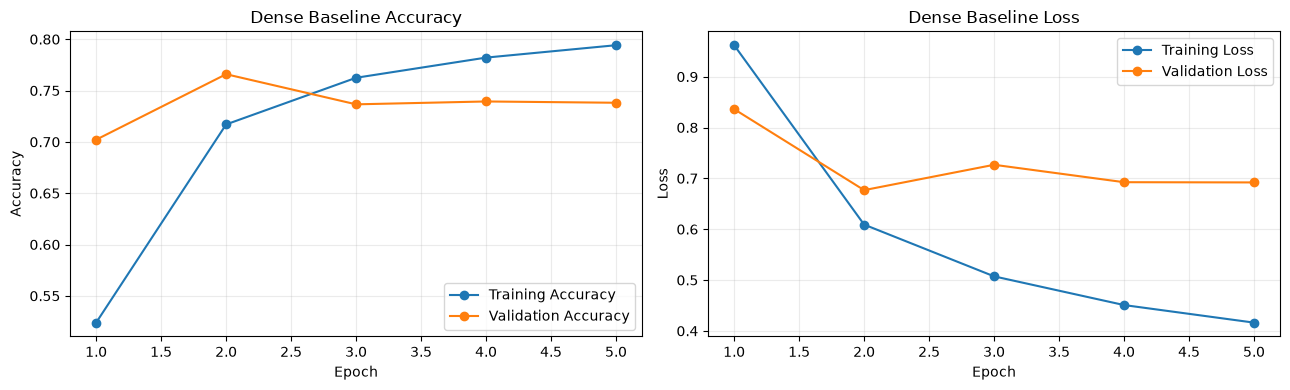

Dense Baseline Results
Best Validation Accuracy: 0.7659
Best Validation Loss: 0.6768
Executed Epochs: 5


In [15]:
plot_training_history(
    dense_history,
    "Dense Baseline"
)

print("Dense Baseline Results")

print(
    "Best Validation Accuracy:",
    f"{max(dense_history.history['val_accuracy']):.4f}"
)

print(
    "Best Validation Loss:",
    f"{min(dense_history.history['val_loss']):.4f}"
)

print(
    "Executed Epochs:",
    len(dense_history.history["loss"])
)

<h3 style="color:#009E73;">Dense Baseline Interpretation</h3>

The Dense model establishes the minimum practical comparison for today's experiment.

The training and validation curves should be examined for:

- Whether both losses decrease.
- Whether validation loss starts increasing while training loss continues decreasing.
- Whether early stopping ends training before the maximum number of epochs.
- The size of the gap between training and validation performance.

A high accuracy value does not automatically mean that all five heartbeat classes are classified well.

The class-level medical metrics will be calculated after all three models have completed training.

<h2 style="color:#0072B2;">3.9 Model 2 — Simple RNN</h2>

The second model processes each heartbeat as an ordered sequence of `187` time steps.

At every time step, the Simple RNN receives:

- The current ECG measurement $x_t$.
- The previous hidden state $h_{t-1}$.

It then produces an updated hidden state:

$$
h_t =
\tanh
\left(
W_xx_t + W_hh_{t-1} + b
\right)
$$

The same recurrent weights are reused across all time steps.

After the final time step, the hidden representation is passed through Dense layers for five-class classification.

The Simple RNN is order-aware, but it has no gates to explicitly control long-term memory.

In [16]:
simple_rnn_model = Sequential([
    Input(shape=(187, 1)),

    SimpleRNN(
        32,
        activation="tanh"
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        5,
        activation="softmax"
    )
])

simple_rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,309 (9.02 KB)

 Trainable params: 2,309 (9.02 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
start_time = time.time()

simple_rnn_history = simple_rnn_model.fit(
    X_train_sequence,
    y_train,
    validation_data=(
        X_validation_sequence,
        y_validation
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks(),
    verbose=1
)

simple_rnn_training_time = (
    time.time() - start_time
)

print(
    "\nSimple RNN training time:",
    f"{simple_rnn_training_time / 60:.2f} minutes"
)

Epoch 1/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.2842 - loss: 1.3862 - val_accuracy: 0.3053 - val_loss: 1.4663
Epoch 2/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.3151 - loss: 1.2577 - val_accuracy: 0.3501 - val_loss: 1.4210
Epoch 3/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.3310 - loss: 1.2242 - val_accuracy: 0.3165 - val_loss: 1.4239
Epoch 4/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.3186 - loss: 1.2956 - val_accuracy: 0.2356 - val_loss: 1.5897
Epoch 5/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.2374 - loss: 1.2754 - val_accuracy: 0.2609 - val_loss: 1.4909

Simple RNN training time: 1.06 minutes


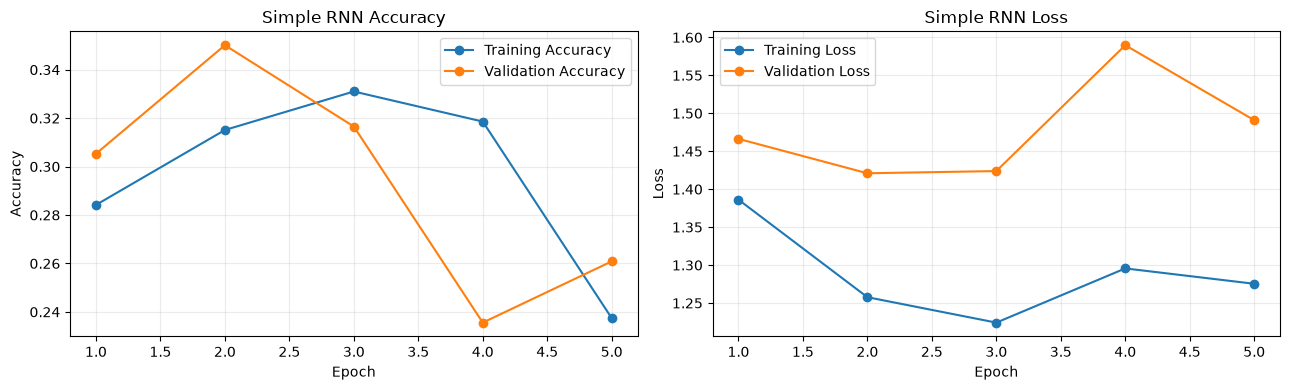

Simple RNN Results
Best Validation Accuracy: 0.3501
Best Validation Loss: 1.4210
Executed Epochs: 5


In [18]:
plot_training_history(
    simple_rnn_history,
    "Simple RNN"
)

print("Simple RNN Results")

print(
    "Best Validation Accuracy:",
    f"{max(simple_rnn_history.history['val_accuracy']):.4f}"
)

print(
    "Best Validation Loss:",
    f"{min(simple_rnn_history.history['val_loss']):.4f}"
)

print(
    "Executed Epochs:",
    len(simple_rnn_history.history["loss"])
)

<h3 style="color:#009E73;">Simple RNN Interpretation</h3>

The Simple RNN introduces an explicit sequential hidden state.

Its results should be compared with the Dense baseline to answer:

- Did sequential processing improve validation performance?
- Did the model improve recognition of rare heartbeat categories?
- Did recurrent processing require more training time?
- Did the validation curves remain stable?
- Did early stopping activate?

The Simple RNN may learn useful local relationships inside the heartbeat, but the hidden state must pass through `187` recurrent steps.

This repeated propagation is what makes the model vulnerable to vanishing gradients.

<h2 style="color:#0072B2;">3.10 Model 3 — LSTM</h2>

The third model replaces the plain recurrent layer with an LSTM layer.

Like the Simple RNN, the LSTM reads the ECG measurements in temporal order.

The difference is that the LSTM maintains:

- A hidden state $h_t$.
- A cell state $c_t$.
- A forget gate.
- An input gate.
- An output gate.

These gates allow the model to learn which parts of the heartbeat should influence later decisions.

The LSTM layer will use the same number of units as the Simple RNN to keep the architecture conceptually comparable.

However, the LSTM will contain more trainable parameters because every memory gate has its own weights.

In [19]:
lstm_model = Sequential([
    Input(shape=(187, 1)),

    LSTM(
        32
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        5,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,573 (21.77 KB)

 Trainable params: 5,573 (21.77 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_sequence,
    y_train,
    validation_data=(
        X_validation_sequence,
        y_validation
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks(),
    verbose=1
)

lstm_training_time = (
    time.time() - start_time
)

print(
    "\nLSTM training time:",
    f"{lstm_training_time / 60:.2f} minutes"
)

Epoch 1/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 154ms/step - accuracy: 0.1584 - loss: 1.5069 - val_accuracy: 0.1048 - val_loss: 1.6219
Epoch 2/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 37s 134ms/step - accuracy: 0.1428 - loss: 1.3108 - val_accuracy: 0.1632 - val_loss: 1.5186
Epoch 3/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 40s 146ms/step - accuracy: 0.2045 - loss: 1.2488 - val_accuracy: 0.2516 - val_loss: 1.4753
Epoch 4/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.3112 - loss: 1.2008 - val_accuracy: 0.2996 - val_loss: 1.4555
Epoch 5/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 38s 139ms/step - accuracy: 0.3481 - loss: 1.1551 - val_accuracy: 0.3168 - val_loss: 1.4491
Epoch 6/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.3459 - loss: 1.1176 - val_accuracy: 0.3425 - val_loss: 1.3372
Epoch 7/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.3675 - loss: 1.0731 - val_accuracy: 0.3543 - val_loss: 1.3215
Epoch 8/12
274/274 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.3242 - loss: 1

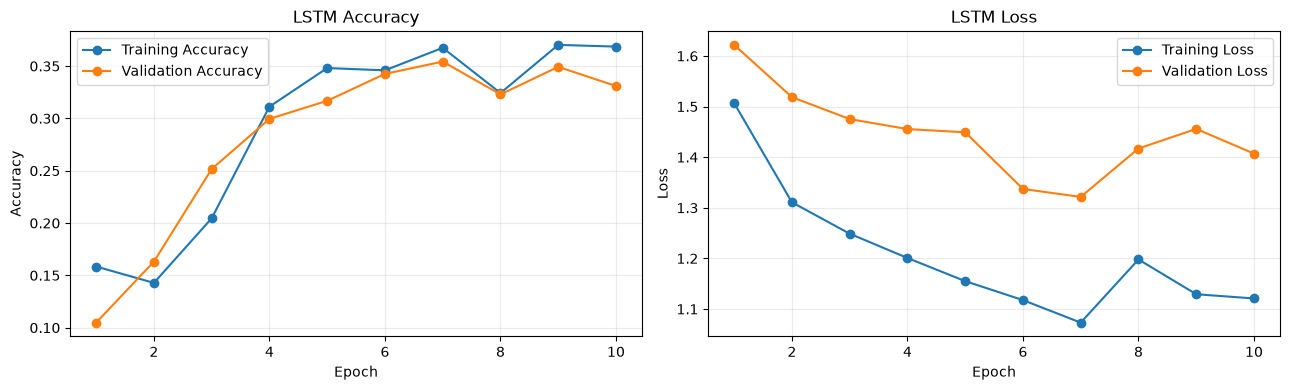

LSTM Results
Best Validation Accuracy: 0.3543
Best Validation Loss: 1.3215
Executed Epochs: 10


In [21]:
plot_training_history(
    lstm_history,
    "LSTM"
)

print("LSTM Results")

print(
    "Best Validation Accuracy:",
    f"{max(lstm_history.history['val_accuracy']):.4f}"
)

print(
    "Best Validation Loss:",
    f"{min(lstm_history.history['val_loss']):.4f}"
)

print(
    "Executed Epochs:",
    len(lstm_history.history["loss"])
)

<h3 style="color:#009E73;">LSTM Interpretation</h3>

The LSTM has now processed each heartbeat using gated memory.

Its performance should be compared with both earlier models.

### Dense versus LSTM

This comparison examines whether an explicit recurrent memory provides an advantage over processing the heartbeat as a fixed vector.

### Simple RNN versus LSTM

This comparison examines whether gated memory provides an advantage over a plain recurrent hidden state.

A stronger LSTM result would suggest that preserving and controlling temporal information helped classification.

A similar or weaker result would not mean that LSTM is incorrect. Possible explanations include:

- The important patterns may be mostly local.
- The sequence may not require long-term memory.
- The model may require different hyperparameters.
- Class imbalance may remain difficult.
- The simpler model may already be sufficient for this processed dataset.

The conclusion must therefore be based on the measured results rather than assuming that the more complex model must win.

<h2 style="color:#0072B2;">3.11 Testing the Importance of Temporal Order</h2>

To directly examine whether temporal order matters, the trained LSTM will be evaluated twice on the validation data:

1. Using the original ECG order.
2. Using the same measurements after applying one fixed random time-step permutation.

The labels and numerical values will remain unchanged. Only the order of the ECG measurements will change.

If performance decreases substantially after permutation, this provides evidence that the model depends on the temporal waveform rather than only the collection of values.

This experiment uses validation data only. The test set remains untouched.

In [22]:
random_generator = np.random.default_rng(
    SEED
)

time_permutation = random_generator.permutation(
    X_validation_sequence.shape[1]
)

X_validation_permuted = (
    X_validation_sequence[
        :,
        time_permutation,
        :
    ]
)

original_probabilities = lstm_model.predict(
    X_validation_sequence,
    batch_size=BATCH_SIZE,
    verbose=0
)

permuted_probabilities = lstm_model.predict(
    X_validation_permuted,
    batch_size=BATCH_SIZE,
    verbose=0
)

original_predictions = np.argmax(
    original_probabilities,
    axis=1
)

permuted_predictions = np.argmax(
    permuted_probabilities,
    axis=1
)

order_experiment = pd.DataFrame([
    {
        "Input Order": "Original ECG Order",
        "Accuracy": accuracy_score(
            y_validation,
            original_predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            original_predictions
        ),
        "Macro Recall": recall_score(
            y_validation,
            original_predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            original_predictions,
            average="macro",
            zero_division=0
        )
    },
    {
        "Input Order": "Permuted Time Steps",
        "Accuracy": accuracy_score(
            y_validation,
            permuted_predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            permuted_predictions
        ),
        "Macro Recall": recall_score(
            y_validation,
            permuted_predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            permuted_predictions,
            average="macro",
            zero_division=0
        )
    }
])

display(order_experiment.round(4))

,Input Order,Accuracy,Balanced Accuracy,Macro Recall,Macro F1
0,Original ECG Order,0.3543,0.5897,0.5897,0.2564
1,Permuted Time Steps,0.0596,0.1993,0.1993,0.0387


<h3 style="color:#009E73;">Order Experiment Interpretation</h3>

This experiment changes only the order of the ECG measurements.

The model receives the same set of values, but the original waveform structure is destroyed.

If the metrics decrease after permutation, the result demonstrates that temporal organization contains useful information.

The relative change in a metric can be understood using:

$$
\text{Relative Drop}
=
\frac{
\text{Original Score}
-
\text{Permuted Score}
}{
\text{Original Score}
}
\times 100
$$

If little change occurs, the model may be relying mainly on local amplitudes, global signal characteristics, or fixed preprocessing patterns rather than long temporal relationships.

The result should be interpreted from the displayed values rather than assuming that a decrease must always occur.

<h2 style="color:#0072B2;">3.12 Medical Validation Metrics</h2>

The three models will now be evaluated on the validation set.

### Accuracy

Accuracy measures the proportion of all correct predictions:

$$
\text{Accuracy}
=
\frac{\text{Correct Predictions}}
{\text{All Predictions}}
$$

Because the normal class is much larger than the other classes, accuracy may hide poor performance on rare categories.

### Recall

For one class, recall is:

$$
\text{Recall}
=
\frac{TP}
{TP+FN}
$$

Recall measures how many real examples of a class were detected.

### Macro Recall

Macro Recall calculates recall separately for every class and then gives all five classes equal weight:

$$
\text{Macro Recall}
=
\frac{1}{K}
\sum_{c=1}^{K}
\text{Recall}_c
$$

### Macro F1

Macro F1 balances precision and recall separately for every class and then averages the results.

### Macro F2

F2 gives recall more importance than precision:

$$
F_2
=
\frac{
5 \times \text{Precision} \times \text{Recall}
}{
4 \times \text{Precision} + \text{Recall}
}
$$

The final model will be selected using validation Macro F2, with Macro Recall as the tie-breaker.

In [23]:
def evaluate_validation_model(
    model,
    validation_input,
    model_name,
    training_seconds
):
    probabilities = model.predict(
        validation_input,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    validation_loss = model.evaluate(
        validation_input,
        y_validation,
        batch_size=BATCH_SIZE,
        verbose=0
    )[0]

    metrics = {
        "Model": model_name,
        "Validation Loss": validation_loss,
        "Accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            predictions
        ),
        "Macro Recall": recall_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_validation,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F2": fbeta_score(
            y_validation,
            predictions,
            beta=2,
            average="macro",
            zero_division=0
        ),
        "Training Time (minutes)": (
            training_seconds / 60
        )
    }

    return metrics, predictions


dense_metrics, dense_validation_predictions = (
    evaluate_validation_model(
        dense_model,
        X_validation,
        "Dense Baseline",
        dense_training_time
    )
)

rnn_metrics, rnn_validation_predictions = (
    evaluate_validation_model(
        simple_rnn_model,
        X_validation_sequence,
        "Simple RNN",
        simple_rnn_training_time
    )
)

lstm_metrics, lstm_validation_predictions = (
    evaluate_validation_model(
        lstm_model,
        X_validation_sequence,
        "LSTM",
        lstm_training_time
    )
)

In [24]:
validation_comparison = pd.DataFrame([
    dense_metrics,
    rnn_metrics,
    lstm_metrics
])

validation_comparison = (
    validation_comparison
    .sort_values(
        by=[
            "Macro F2",
            "Macro Recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_comparison.round(4)
)

print(
    "Selected validation model:",
    validation_comparison.iloc[0]["Model"]
)

print(
    "Selection rule:",
    "Highest Macro F2, with Macro Recall as tie-breaker."
)

,Model,Validation Loss,Accuracy,Balanced Accuracy,Macro Recall,Macro F1,Macro F2,Training Time (minutes)
0,Dense Baseline,0.6768,0.7659,0.8054,0.8054,0.5482,0.6230,0.1389
1,LSTM,1.3215,0.3543,0.5897,0.5897,0.2564,0.3311,6.5381
2,Simple RNN,1.4210,0.3501,0.5397,0.5397,0.2151,0.2671,1.0561


Selected validation model: Dense Baseline
Selection rule: Highest Macro F2, with Macro Recall as tie-breaker.


In [25]:
validation_prediction_sets = {
    "Dense Baseline": dense_validation_predictions,
    "Simple RNN": rnn_validation_predictions,
    "LSTM": lstm_validation_predictions
}

target_names = [
    class_names[class_id]
    for class_id in range(5)
]

for model_name, predictions in (
    validation_prediction_sets.items()
):
    print("\n", "=" * 70)
    print(model_name)
    print("=" * 70)

    model_report = classification_report(
        y_validation,
        predictions,
        labels=list(range(5)),
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )

    model_report_table = (
        pd.DataFrame(model_report)
        .transpose()
        .loc[
            target_names,
            [
                "precision",
                "recall",
                "f1-score",
                "support"
            ]
        ]
    )

    display(
        model_report_table.round(4)
    )


Dense Baseline


,precision,recall,f1-score,support
N - Normal,0.9777,0.7534,0.8510,14494.0
S - Supraventricular,0.2003,0.7011,0.3115,445.0
V - Ventricular,0.5322,0.7556,0.6246,1158.0
F - Fusion,0.0761,0.8906,0.1401,128.0
Q - Unclassified,0.7258,0.9261,0.8138,1286.0



Simple RNN


,precision,recall,f1-score,support
N - Normal,0.9528,0.3163,0.4750,14494.0
S - Supraventricular,0.0673,0.5663,0.1202,445.0
V - Ventricular,0.0588,0.0086,0.0151,1158.0
F - Fusion,0.0260,0.8984,0.0504,128.0
Q - Unclassified,0.2687,0.9090,0.4148,1286.0



LSTM


,precision,recall,f1-score,support
N - Normal,0.9556,0.2986,0.4550,14494.0
S - Supraventricular,0.0617,0.6989,0.1134,445.0
V - Ventricular,0.1390,0.2383,0.1756,1158.0
F - Fusion,0.0697,0.7891,0.1281,128.0
Q - Unclassified,0.2634,0.9238,0.4099,1286.0


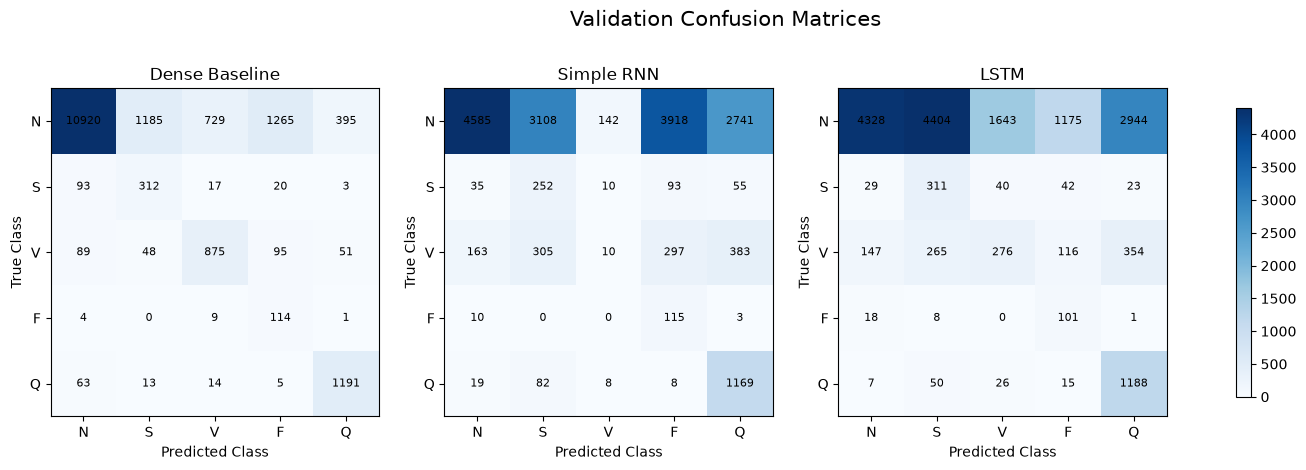

In [26]:
class_symbols = [
    "N",
    "S",
    "V",
    "F",
    "Q"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for axis, (
    model_name,
    predictions
) in zip(
    axes,
    validation_prediction_sets.items()
):
    matrix = confusion_matrix(
        y_validation,
        predictions,
        labels=list(range(5))
    )

    image = axis.imshow(
        matrix,
        cmap="Blues"
    )

    axis.set_title(model_name)
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("True Class")

    axis.set_xticks(
        range(5),
        class_symbols
    )

    axis.set_yticks(
        range(5),
        class_symbols
    )

    for row in range(5):
        for column in range(5):
            axis.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                fontsize=8
            )

fig.colorbar(
    image,
    ax=axes,
    shrink=0.75
)

plt.suptitle(
    "Validation Confusion Matrices",
    fontsize=15
)

plt.show()

<h2 style="color:#0072B2;">3.13 Validation Comparison and Model Selection</h2>

The comparison table answers three separate questions.

### Did Sequential Processing Help?

The Dense baseline is compared with the Simple RNN and LSTM.

If a recurrent model achieves stronger Macro Recall or Macro F2, sequential processing provided a practical advantage.

### Did Gated Memory Help?

The Simple RNN is compared directly with the LSTM.

If the LSTM performs better, its gates likely helped preserve and control useful temporal information.

If the Simple RNN performs similarly or better, the important ECG patterns may not require long-term gated memory, or the current LSTM configuration may require further tuning.

### Did the Model Treat All Classes Fairly?

The class-level reports and confusion matrices show whether high overall accuracy was caused mainly by the normal class.

The selected model is the model with the highest validation Macro F2. Macro Recall is used as the tie-breaker because missing rare abnormal heartbeat categories is more important than obtaining a high majority-class accuracy.

No test-set result has been used during this selection.

In [27]:
model_registry = {
    "Dense Baseline": {
        "model": dense_model,
        "validation_input": X_validation,
        "test_input": X_test
    },
    "Simple RNN": {
        "model": simple_rnn_model,
        "validation_input": X_validation_sequence,
        "test_input": X_test_sequence
    },
    "LSTM": {
        "model": lstm_model,
        "validation_input": X_validation_sequence,
        "test_input": X_test_sequence
    }
}

selected_model_name = (
    validation_comparison
    .iloc[0]["Model"]
)

selected_model_information = (
    model_registry[selected_model_name]
)

selected_model = (
    selected_model_information["model"]
)

selected_test_input = (
    selected_model_information["test_input"]
)

print(
    "Final selected model:",
    selected_model_name
)

print(
    "The test set is now ready for its first final evaluation."
)

Final selected model: Dense Baseline
The test set is now ready for its first final evaluation.


<h2 style="color:#0072B2;">3.14 Final Test Evaluation</h2>

The final model has already been selected using validation data.

The untouched test set can now be used once to estimate how the selected model performs on unseen heartbeats.

The test result will not be used to return to the earlier models or change the selection decision.

The final evaluation will report:

- Test loss.
- Accuracy.
- Balanced Accuracy.
- Macro Recall.
- Macro F1.
- Macro F2.
- Recall for every heartbeat category.
- The final confusion matrix.

In [28]:
test_probabilities = selected_model.predict(
    selected_test_input,
    batch_size=BATCH_SIZE,
    verbose=0
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

test_loss = selected_model.evaluate(
    selected_test_input,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0
)[0]

final_test_results = pd.DataFrame([{
    "Selected Model": selected_model_name,
    "Test Loss": test_loss,
    "Test Accuracy": accuracy_score(
        y_test,
        test_predictions
    ),
    "Test Balanced Accuracy": balanced_accuracy_score(
        y_test,
        test_predictions
    ),
    "Test Macro Recall": recall_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    ),
    "Test Macro F1": f1_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0
    ),
    "Test Macro F2": fbeta_score(
        y_test,
        test_predictions,
        beta=2,
        average="macro",
        zero_division=0
    )
}])

display(
    final_test_results.round(4)
)

final_classification_report = (
    classification_report(
        y_test,
        test_predictions,
        labels=list(range(5)),
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )
)

final_classification_table = (
    pd.DataFrame(
        final_classification_report
    )
    .transpose()
    .loc[
        target_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
)

display(
    final_classification_table.round(4)
)

,Selected Model,Test Loss,Test Accuracy,Test Balanced Accuracy,Test Macro Recall,Test Macro F1,Test Macro F2
0,Dense Baseline,0.6796,0.7632,0.7985,0.7985,0.5448,0.6182


,precision,recall,f1-score,support
N - Normal,0.9763,0.7516,0.8494,18118.0
S - Supraventricular,0.1928,0.6888,0.3012,556.0
V - Ventricular,0.5380,0.7569,0.6290,1448.0
F - Fusion,0.0760,0.8827,0.1399,162.0
Q - Unclassified,0.7198,0.9123,0.8047,1608.0


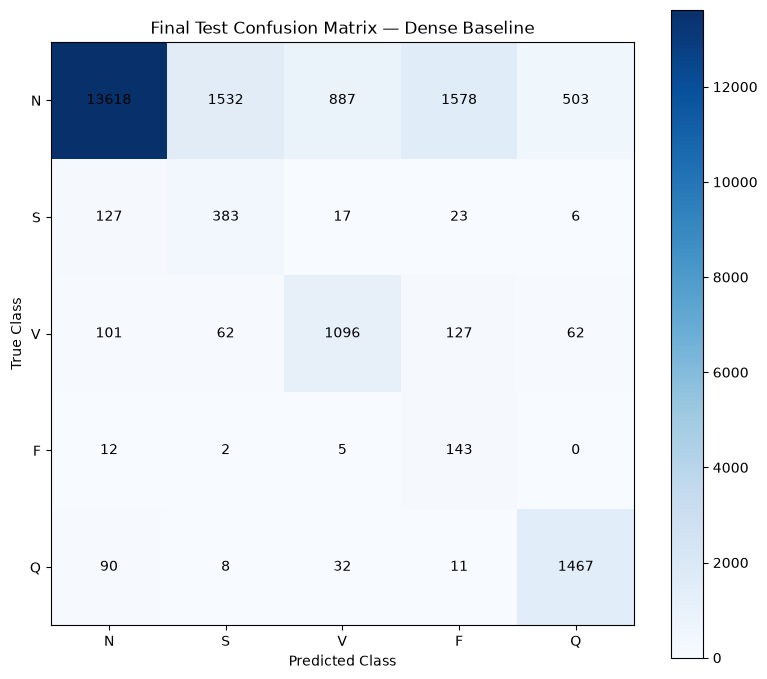

Saved model: day3_best_ecg_model.keras


In [29]:
final_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=list(range(5))
)

plt.figure(figsize=(8, 7))

plt.imshow(
    final_confusion_matrix,
    cmap="Blues"
)

plt.title(
    f"Final Test Confusion Matrix — {selected_model_name}"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(5),
    class_symbols
)

plt.yticks(
    range(5),
    class_symbols
)

for row in range(5):
    for column in range(5):
        plt.text(
            column,
            row,
            final_confusion_matrix[row, column],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

selected_model.save(
    "day3_best_ecg_model.keras"
)

print(
    "Saved model:",
    "day3_best_ecg_model.keras"
)

<h2 style="color:#0072B2;">Day 3 Conclusion</h2>

This notebook studied why ECG heartbeats should be treated as ordered sequential data and compared three different classification approaches:

1. A Dense non-recurrent baseline.
2. A Simple RNN with a recurrent hidden state.
3. An LSTM with gated memory.

### Validation Results

The Dense baseline achieved the strongest validation result:

- Validation Accuracy: `0.7659`
- Macro Recall: `0.8054`
- Macro F1: `0.5482`
- Macro F2: `0.6230`

The LSTM achieved:

- Validation Accuracy: `0.3543`
- Macro Recall: `0.5897`
- Macro F1: `0.2564`
- Macro F2: `0.3311`

The Simple RNN achieved:

- Validation Accuracy: `0.3501`
- Macro Recall: `0.5397`
- Macro F1: `0.2151`
- Macro F2: `0.2671`

The Dense baseline was therefore selected because it achieved the highest validation Macro F2 and Macro Recall.

### Why Did the Dense Model Win?

The result shows that a more complex sequential architecture does not automatically provide better performance.

The heartbeats were already segmented, normalized, aligned, and padded to a fixed length. This allowed the Dense model to learn strong patterns from fixed ECG positions without maintaining a recurrent state across all `187` time steps.

The recurrent models also used class weights to address the severe class imbalance. The very large weight assigned to the rare Fusion class encouraged the models to detect more rare examples, but it also produced many false-positive predictions.

### Did Temporal Order Still Matter?

Yes.

When the LSTM received the original ECG order, it achieved:

- Accuracy: `0.3543`
- Macro Recall: `0.5897`

After randomly permuting the time steps, its performance decreased to:

- Accuracy: `0.0596`
- Macro Recall: `0.1993`

Therefore, the LSTM was using temporal order. However, using order did not guarantee that it would outperform the Dense baseline under the current architecture and training settings.

### Final Test Result

The selected Dense model achieved the following results on the untouched test set:

- Test Accuracy: `0.7632`
- Test Balanced Accuracy: `0.7985`
- Test Macro Recall: `0.7985`
- Test Macro F1: `0.5448`
- Test Macro F2: `0.6182`

The similarity between validation and test results indicates that the selected model generalized consistently to the provided test data.

### Final Learning Outcome

The experiment demonstrated the difference between ordinary feature processing, recurrent hidden-state memory, and gated LSTM memory.

It also showed that model selection must depend on measured validation results rather than assuming that the most complex architecture will always be the strongest.